# AI & Data Jobs — Five Tables, Two Salary Leaks, and a Pay Premium That Is Not There
> **36,000 postings across 5 joinable tables** | [Dataset](https://www.kaggle.com/datasets/lorenzoscaturchio/ai-data-jobs-skills-salaries-2024-2026)

| File | Rows | Columns | What it is |
| --- | ---: | ---: | --- |
| `jobs.csv` | 36,000 | 37 | one row per posting |
| `job_skills.csv` | 318,014 | 6 | one row per (posting, skill) — the biggest table here |
| `companies.csv` | 280 | 15 | employer profiles |
| `salary_benchmarks.csv` | 618 | 10 | pay percentiles per (title, country, seniority, remote) |
| `skill_demand_monthly.csv` | 1,080 | 7 | skill volume and pay by month |

Section 1 reprints those shapes from the files, so you never have to take a markdown
table's word for it. Most notebooks on this dataset read `jobs.csv` and stop; the other
four tables are where both the leaks and the one real finding live.

## TL;DR

- **`salary_min_usd` and `salary_max_usd` are the target.** The generator draws them
  *from* `salary_mid_usd` (min ≈ mid × U(0.82, 0.90), max ≈ mid × U(1.10, 1.22), before rounding). They
  correlate with it at **r = 0.997** and **0.997**. Leaving them in a salary model cuts
  cross-validated MAE from **$8,664 to $2,620** — it hides 70% of the real error.
- **`salary_benchmarks.csv` is a second leak, and it is a whole table.** Every column in
  it is an aggregate of `jobs.salary_mid_usd`, computed over a group that contains the
  row you are predicting. Joined back on, `salary_median_usd` correlates **0.920** with
  the row's own target.
- **The other tables do not pay.** Adding 5 skill aggregates and 6 company attributes
  moves MAE from **$8,664 to $8,807** — slightly worse. That is a finding, not a
  failure: it says the salary signal is already fully carried by title, seniority and
  country.
- **The "GenAI skills pay +$21k" headline is a confound.** GenAI skills appear in only 3
  of the 8 role families and never in the other 5. Inside a matched
  (title, seniority, country, remote) cell the median premium is **$500**, and only
  **52.9%** of comparable cells are positive at all.
- The data is **synthetic**, produced by the seeded `create_dataset.py` that ships with
  the dataset. Good for teaching leakage, joins and confounding; not evidence about the
  real labour market.

## Contents

1. [Setup & data loading](#setup)
2. [Objective & evaluation plan](#objective)
3. [Data overview](#overview)
4. [Missing data](#missing)
5. [Numeric distributions](#distributions)
6. [Categoricals](#categorical)
7. [Correlations & the leakage audit](#correlations)
8. [The second leak: a whole table of target aggregates](#table-leak)
9. [Target analysis](#target)
10. [What the leak costs](#worth)
11. [Does the multi-table join pay?](#join)
12. [The GenAI premium that is not there](#genai)
13. [Evaluation readiness](#evaluation)
14. [Key findings & takeaways](#findings)

## 1. Setup & Data Loading <a id='setup'></a>

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 90
plt.rcParams["font.size"] = 11

MOUNT_GUESS = "/kaggle/input/ai-data-jobs-skills-salaries-2024-2026"
MARKER = "jobs.csv"


def _find_data_dir(marker):
    # Locate the dataset wherever Kaggle mounted it. Two earlier guesses failed
    # here: the exact path /kaggle/input/<slug> did not exist, and falling back
    # to "." landed in the kernel working directory, which holds no CSVs at all,
    # so the notebook died on a confusing FileNotFoundError several cells later.
    # The files mount NESTED (the run that taught us this found only
    # /kaggle/input/datasets). Walk the mount tree for the file we actually
    # need, and if it is absent report what *was* mounted, so the next failure
    # is diagnosable rather than another guess.
    exact = os.path.join(MOUNT_GUESS, marker)
    if os.path.exists(exact):
        return MOUNT_GUESS
    if os.path.isdir("/kaggle/input"):
        for root, _dirs, files in os.walk("/kaggle/input"):
            if marker in files:
                return root
    if os.path.exists(marker):
        return "."
    seen = []
    if os.path.isdir("/kaggle/input"):
        for root, _dirs, files in os.walk("/kaggle/input"):
            seen.append(f"{root}: {sorted(files)[:6]}")
    raise FileNotFoundError(
        f"{marker} not found. Searched /kaggle/input and the working dir. "
        f"Mounted: {seen or 'nothing under /kaggle/input'}. "
        "Attach the dataset to this notebook (Add Input) and re-run."
    )


DATA_DIR = _find_data_dir(MARKER)
print(f"Reading from: {DATA_DIR}")

Reading from: .


In [2]:
TABLES = ["jobs", "companies", "job_skills", "salary_benchmarks", "skill_demand_monthly"]
frames = {name: pd.read_csv(f"{DATA_DIR}/{name}.csv") for name in TABLES}

jobs = frames["jobs"]
companies = frames["companies"]
job_skills = frames["job_skills"]
salary_benchmarks = frames["salary_benchmarks"]
skill_demand = frames["skill_demand_monthly"]

# Sections 3-9 profile the posting table; the other four are joined on from section 8.
df = jobs

print(f"{'file':<28} {'rows':>9} {'cols':>6}   memory")
print("-" * 58)
for name in TABLES:
    frame = frames[name]
    mem = frame.memory_usage(deep=True).sum() / 1e6
    print(f"{name + '.csv':<28} {len(frame):>9,} {frame.shape[1]:>6}   {mem:>7.1f} MB")
print("-" * 58)
print(f"{'total rows':<28} {sum(len(f) for f in frames.values()):>9,}")
print()
print("Foreign keys resolve:")
print(f"  job_skills.job_id -> jobs      {job_skills['job_id'].isin(jobs['job_id']).mean():>7.2%}")
print(f"  jobs.company_id  -> companies  {jobs['company_id'].isin(companies['company_id']).mean():>7.2%}")

file                              rows   cols   memory
----------------------------------------------------------
jobs.csv                        36,000     37      28.3 MB
companies.csv                      280     15       0.1 MB
job_skills.csv                 318,014      6      27.9 MB
salary_benchmarks.csv              618     10       0.1 MB
skill_demand_monthly.csv         1,080      7       0.1 MB
----------------------------------------------------------
total rows                     355,992

Foreign keys resolve:
  job_skills.job_id -> jobs      100.00%
  jobs.company_id  -> companies  100.00%


In [3]:
jobs.head()

,job_id,company_id,company_name,posted_date,job_title,role_family,seniority,employment_type,remote_type,city,country,region,industry,company_size,funding_stage,company_type,salary_currency,salary_min_usd,salary_max_usd,salary_mid_usd,bonus_target_pct,equity_offered,experience_min_years,experience_max_years,education_required,visa_sponsorship,ai_focus_area,primary_skill_cluster,cloud_stack,llm_stack,required_skills,skills_count,applications_30d,days_open,is_filled,hiring_urgency,description
0,JOB000001,COMP0131,Signal Academy,2025-07-22,Data Engineer,data-platform,senior,full_time,remote,"New York, NY",United States,North America,education,startup,series-b,edtech,USD,139000,191000,157000,0.093,1,5,9,master,1,batch-pipelines,data-platform,Azure|Databricks,NaN,Python|Azure|BigQuery|dbt|GCP|Kafka|AWS|Data M...,12,53,28,0,medium,Signal Academy is looking for a senior Data En...
1,JOB000002,COMP0189,Foundry Advisory 189,2024-11-08,Data Analyst,analytics,senior,full_time,hybrid,"San Francisco, CA",United States,North America,consulting,large,late-stage,advisory,USD,183000,257000,212000,0.079,0,5,8,bachelor,0,operations,analytics,Azure,NaN,SQL|Python|Statistics|Excel|Azure|Pandas|Looke...,8,57,32,0,medium,Foundry Advisory 189 is looking for a senior D...
2,JOB000003,COMP0241,Apex Learning 241,2025-10-27,MLOps Engineer,ml-operations,entry,full_time,onsite,"Vancouver, BC",Canada,North America,education,large,public,edtech,USD,71000,91000,82000,0.077,0,1,3,bachelor,1,governance,mlops,GCP,NaN,Docker|Azure|Model Monitoring|Feature Store|AW...,8,28,38,0,medium,Apex Learning 241 is looking for a entry MLOps...
3,JOB000004,COMP0072,Meridian Markets,2024-10-23,Analytics Engineer,analytics,senior,full_time,remote,"Sydney, Australia",Australia,APAC,finance,medium,series-d,asset-manager,USD,154000,210000,182000,0.128,0,6,8,bachelor,0,metrics,analytics,GCP|BigQuery,NaN,SQL|BigQuery|Looker|Data Modeling|dbt|Snowflak...,7,69,41,0,low,Join Meridian Markets as a senior Analytics En...
4,JOB000005,COMP0083,Signal Finance,2025-09-08,ML Engineer,ml-engineering,staff,contract,hybrid,"Austin, TX",United States,North America,finance,startup,series-b,fintech,USD,173000,230000,200000,0.151,0,8,11,master,0,serving,ml-engineering,Azure|Databricks,NaN,TensorFlow|Docker|Feature Store|Spark|Airflow|...,10,49,45,1,low,Join Signal Finance as a staff ML Engineer wor...


## 2. Objective & Evaluation Plan <a id='objective'></a>

**Objective:** predict `salary_mid_usd` — the midpoint of the posted band — from what a
job seeker can see before the band is disclosed.

**Why that target:** it is the question the table exists to answer, and it is also the
column three other columns are secretly built out of, which makes it a good place to
learn what leakage costs.

**Validation:** 5-fold `GroupKFold` on `company_id`. Postings from the same employer
share pay bands by construction, so a random split would put near-duplicate rows on both
sides of the fold and reward memorising employers. There are 280 companies over 36,000
postings, so this matters.

**Metric:** MAE in dollars, with R² alongside. MAE is the honest one here **because**
salary is right-skewed and a squared-error metric would be decided by the principal-level
tail.

**Baseline to beat:** predicting the global median salary for every posting.

In [4]:
TARGET_COL = "salary_mid_usd"
MODELING_TASK = "regression"
PRIMARY_METRIC = "MAE in USD (R2 alongside)"
VALIDATION_PLAN = "5-fold GroupKFold on company_id"

print("Objective framing")
print("-" * 62)
print(f"Rows available      : {len(jobs):,} postings")
print(f"Groups              : {jobs['company_id'].nunique()} companies "
      f"({len(jobs) / jobs['company_id'].nunique():.0f} postings each on average)")
print(f"Target              : {TARGET_COL}")
print(f"Modeling task       : {MODELING_TASK}")
print(f"Primary metric      : {PRIMARY_METRIC}")
print(f"Validation plan     : {VALIDATION_PLAN}")
print()
print(jobs[TARGET_COL].describe().round(0).to_string())

Objective framing
--------------------------------------------------------------
Rows available      : 36,000 postings
Groups              : 280 companies (129 postings each on average)
Target              : salary_mid_usd
Modeling task       : regression
Primary metric      : MAE in USD (R2 alongside)
Validation plan     : 5-fold GroupKFold on company_id

count     36000.0
mean     154232.0
std       59020.0
min       30000.0
25%      111000.0
50%      149000.0
75%      191000.0
max      470000.0


## 3. Data Overview <a id='overview'></a>

In [5]:
print("Column types:")
print(df.dtypes.value_counts().to_string())
print(f"\nDuplicate rows: {df.duplicated().sum():,}")
print(f"Total missing values: {df.isnull().sum().sum():,}")
print()
df.describe().round(2)

Column types:
str        25
int64      11
float64     1

Duplicate rows: 0
Total missing values: 27,861



,salary_min_usd,salary_max_usd,salary_mid_usd,bonus_target_pct,equity_offered,experience_min_years,experience_max_years,visa_sponsorship,skills_count,applications_30d,days_open,is_filled
count,36000.00,36000.00,36000.00,36000.00,36000.00,36000.00,36000.00,36000.00,36000.00,36000.00,36000.00,36000.00
mean,132659.11,178970.00,154232.22,0.10,0.38,4.28,7.22,0.16,8.83,45.71,31.23,0.78
std,50881.67,68778.93,59020.49,0.02,0.49,3.02,3.53,0.37,1.54,14.97,10.10,0.42
min,25000.00,33000.00,30000.00,0.03,0.00,0.00,2.00,0.00,6.00,4.00,6.00,0.00
25%,96000.00,129000.00,111000.00,0.08,0.00,2.00,5.00,0.00,8.00,36.00,24.00,1.00
50%,128000.00,173000.00,149000.00,0.10,0.00,3.00,6.00,0.00,9.00,46.00,31.00,1.00
75%,164000.00,222000.00,191000.00,0.11,1.00,6.00,9.00,0.00,10.00,56.00,38.00,1.00
max,409000.00,540000.00,470000.00,0.20,1.00,11.00,16.00,1.00,12.00,104.00,76.00,1.00


## 4. Missing Data <a id='missing'></a>

One column is missing at scale, and it is missing for a reason worth knowing before you
impute it.

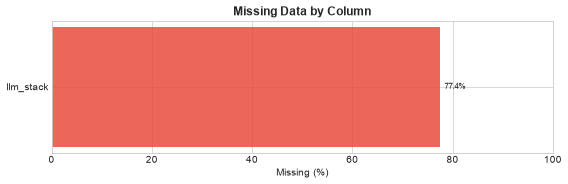

           count  percent
llm_stack  27861     77.4

llm_stack is missing where the posting has no LLM requirement at all:
llm_stack       False  True 
role_family                 
analytics       0.340  0.000
data-platform   0.149  0.000
genai-apps      0.000  0.708
ml-engineering  0.147  0.000
ml-operations   0.088  0.000
modeling        0.242  0.000
product         0.033  0.030
research        0.000  0.261

So NaN here means 'not applicable', not 'unrecorded'. Imputing a mode would
invent an LLM stack for analytics and data-platform roles that never had one.


In [6]:
missing = df.isnull().sum()
missing_df = pd.DataFrame({"count": missing, "percent": (missing / len(df) * 100).round(1)})
missing_df = missing_df[missing_df["count"] > 0].sort_values("percent", ascending=False)

if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(9, max(3, len(missing_df) * 0.6)))
    bars = ax.barh(missing_df.index, missing_df["percent"], color="#e74c3c", alpha=0.85)
    ax.set_xlim(0, 100)
    ax.set_xlabel("Missing (%)")
    ax.set_title("Missing Data by Column", fontweight="bold")
    for bar, pct in zip(bars, missing_df["percent"]):
        ax.text(pct + 1, bar.get_y() + bar.get_height() / 2, f"{pct:.1f}%",
                va="center", fontsize=9)
    plt.tight_layout()
    plt.show()
    print(missing_df.to_string())
else:
    print("No missing values found.")

print()
print("llm_stack is missing where the posting has no LLM requirement at all:")
present = df["llm_stack"].notna()
print(df.groupby(present)["role_family"].value_counts(normalize=True)
      .unstack(0).fillna(0).round(3).to_string())
print()
print("So NaN here means 'not applicable', not 'unrecorded'. Imputing a mode would")
print("invent an LLM stack for analytics and data-platform roles that never had one.")

## 5. Numeric Distributions <a id='distributions'></a>

Three of these panels are the same picture, which is the first visible sign of the leak
that Section 7 measures: `salary_min_usd`, `salary_mid_usd` and `salary_max_usd` are the
same distribution shifted, because two of them are generated from the third.

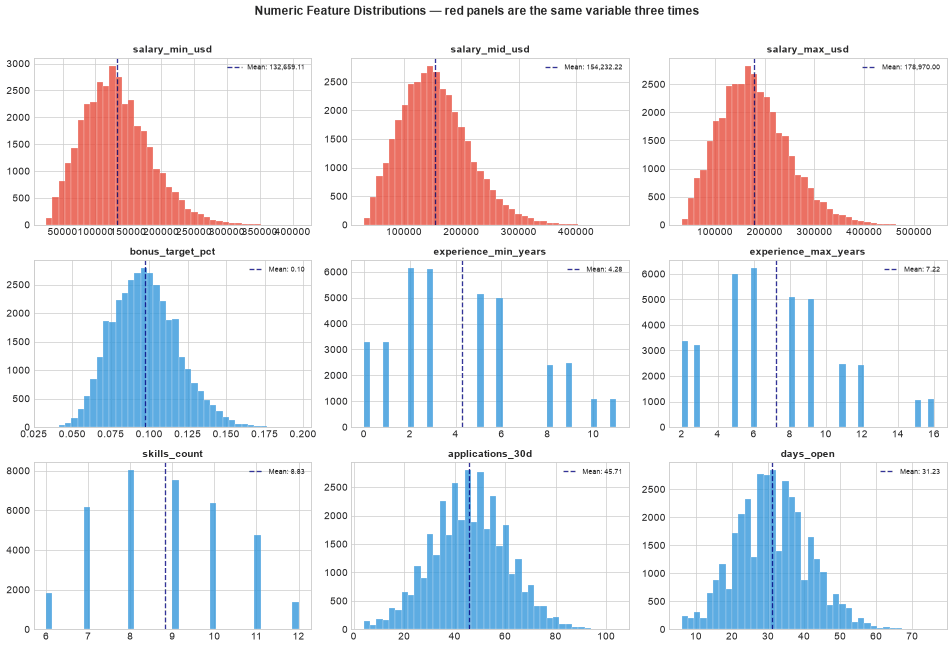

In [7]:
NUMERIC_COLS = ["salary_min_usd", "salary_mid_usd", "salary_max_usd", "bonus_target_pct",
                "experience_min_years", "experience_max_years", "skills_count",
                "applications_30d", "days_open"]

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for ax, col in zip(axes, NUMERIC_COLS):
    color = "#e74c3c" if col.startswith("salary_") else "#3498db"
    ax.hist(df[col].dropna(), bins=40, color=color, alpha=0.8,
            edgecolor="white", linewidth=0.3)
    ax.axvline(df[col].mean(), color="navy", linestyle="--", alpha=0.8,
               label=f"Mean: {df[col].mean():,.2f}")
    ax.set_title(col, fontweight="bold", fontsize=11)
    ax.legend(fontsize=8)

plt.suptitle("Numeric Feature Distributions — red panels are the same variable three times",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 6. Categoricals <a id='categorical'></a>

Note `role_family` in particular. It has 8 values, it is close to balanced, and it turns
out to be the column that explains away the GenAI pay premium in Section 12.

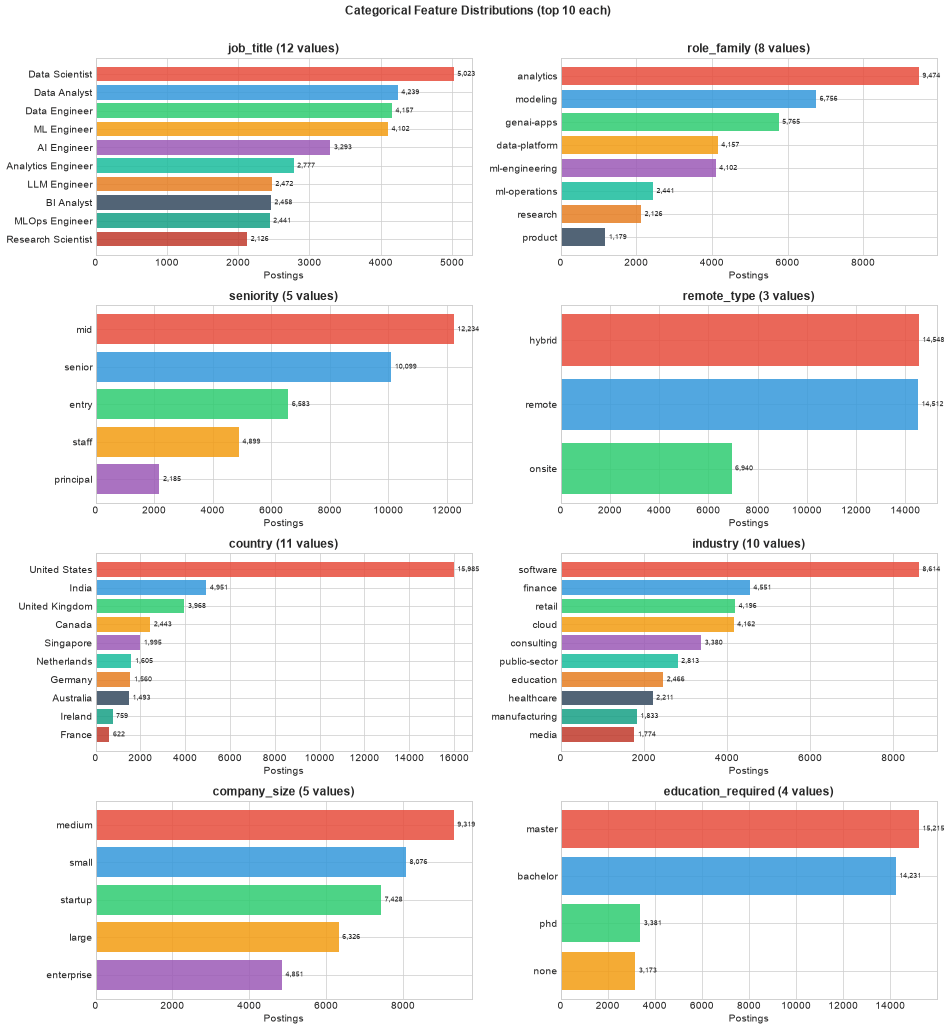

In [8]:
CAT_COLS = ["job_title", "role_family", "seniority", "remote_type",
            "country", "industry", "company_size", "education_required"]
palette = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12", "#9b59b6",
           "#1abc9c", "#e67e22", "#34495e", "#16a085", "#c0392b"]

fig, axes = plt.subplots(4, 2, figsize=(15, 16))
axes = axes.flatten()
for ax, col in zip(axes, CAT_COLS):
    counts = df[col].value_counts().head(10)
    bars = ax.barh(counts.index.astype(str), counts.values,
                   color=[palette[i % len(palette)] for i in range(len(counts))],
                   alpha=0.85)
    ax.invert_yaxis()
    ax.set_title(f"{col} ({df[col].nunique()} values)", fontweight="bold")
    ax.set_xlabel("Postings")
    for bar, val in zip(bars, counts.values):
        ax.text(val + counts.max() * 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:,}", va="center", fontsize=8)

plt.suptitle("Categorical Feature Distributions (top 10 each)", fontsize=14,
             fontweight="bold", y=1.005)
plt.tight_layout()
plt.show()

## 7. Correlations & the Leakage Audit <a id='correlations'></a>

The heatmap first, then the audit that explains its top row. Two features correlate with
the target above **0.99**, which is not a strong predictor — it is the target itself
wearing a different name.

**The test.** If `salary_min_usd` were an independent measurement, the ratio
`salary_min_usd / salary_mid_usd` would vary with role, seniority and country. If it is
drawn *from* the target by a fixed multiplier, the ratio will sit inside a narrow band
regardless of anything else. The next two cells check which it is.

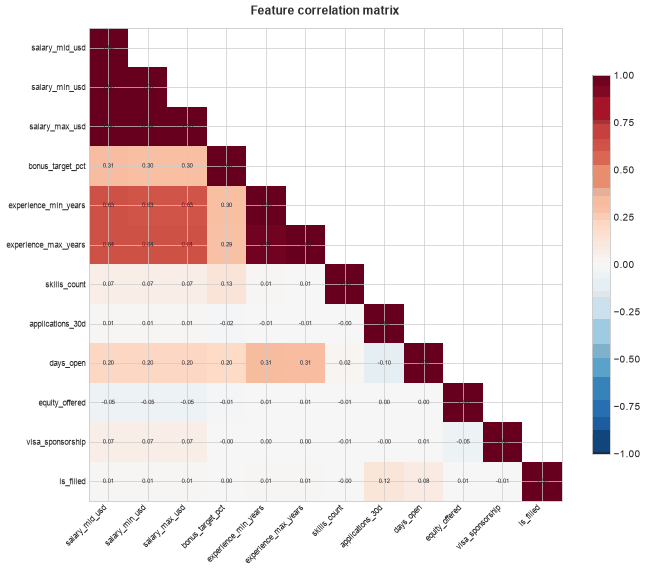

Correlation with salary_mid_usd, every numeric column:
--------------------------------------------------------
  salary_min_usd           +0.9972  <-- LEAK
  salary_max_usd           +0.9965  <-- LEAK
  experience_max_years     +0.6403
  experience_min_years     +0.6336
  bonus_target_pct         +0.3051
  days_open                +0.2047
  skills_count             +0.0697
  visa_sponsorship         +0.0662
  equity_offered           -0.0545
  is_filled                +0.0104
  applications_30d         +0.0090


In [9]:
CORR_COLS = ["salary_mid_usd", "salary_min_usd", "salary_max_usd", "bonus_target_pct",
             "experience_min_years", "experience_max_years", "skills_count",
             "applications_30d", "days_open", "equity_offered", "visa_sponsorship",
             "is_filled"]
corr = df[CORR_COLS].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
im = ax.imshow(corr.mask(mask), cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(CORR_COLS)))
ax.set_xticklabels(CORR_COLS, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(CORR_COLS)))
ax.set_yticklabels(CORR_COLS, fontsize=9)
for i in range(len(CORR_COLS)):
    for j in range(i + 1):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Feature correlation matrix", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

print(f"Correlation with {TARGET_COL}, every numeric column:")
print("-" * 56)
target_corr = corr[TARGET_COL].drop(TARGET_COL).sort_values(key=abs, ascending=False)
for name, value in target_corr.items():
    flag = "  <-- LEAK" if abs(value) > 0.9 else ""
    print(f"  {name:<24} {value:>+7.4f}{flag}")

In [10]:
# Is the band drawn from the midpoint, or measured alongside it?
ratio_min = df["salary_min_usd"] / df[TARGET_COL]
ratio_max = df["salary_max_usd"] / df[TARGET_COL]

print("If min/max were independent measurements, these ratios would vary by role,")
print("seniority and country. Here is their entire observed range:")
print()
print(f"{'ratio':<28} {'min':>8} {'p25':>8} {'median':>8} {'p75':>8} {'max':>8}")
print("-" * 72)
for label, ratio in [("salary_min / salary_mid", ratio_min),
                     ("salary_max / salary_mid", ratio_max)]:
    q = ratio.quantile([0, 0.25, 0.5, 0.75, 1.0])
    print(f"{label:<28} {q[0]:>8.3f} {q[0.25]:>8.3f} {q[0.5]:>8.3f} "
          f"{q[0.75]:>8.3f} {q[1.0]:>8.3f}")

print()
print("Spread of the ratio inside each seniority level (max - min):")
for level, group in df.groupby("seniority"):
    r = group["salary_min_usd"] / group[TARGET_COL]
    print(f"  {level:<10} {r.min():.3f} to {r.max():.3f}")

print()
print("The band is a fixed multiplicative envelope around the midpoint: min is a draw")
print("from roughly U(0.82, 0.90) x mid and max from U(1.10, 1.22) x mid, with no")
print("dependence on role or level. Therefore both columns are the target, rescaled.")

If min/max were independent measurements, these ratios would vary by role,
seniority and country. Here is their entire observed range:

ratio                             min      p25   median      p75      max
------------------------------------------------------------------------
salary_min / salary_mid         0.810    0.840    0.860    0.880    0.912
salary_max / salary_mid         1.091    1.130    1.160    1.190    1.229

Spread of the ratio inside each seniority level (max - min):
  entry      0.810 to 0.912
  mid        0.812 to 0.907
  principal  0.815 to 0.902
  senior     0.815 to 0.906
  staff      0.817 to 0.902

The band is a fixed multiplicative envelope around the midpoint: min is a draw
from roughly U(0.82, 0.90) x mid and max from U(1.10, 1.22) x mid, with no
dependence on role or level. Therefore both columns are the target, rescaled.


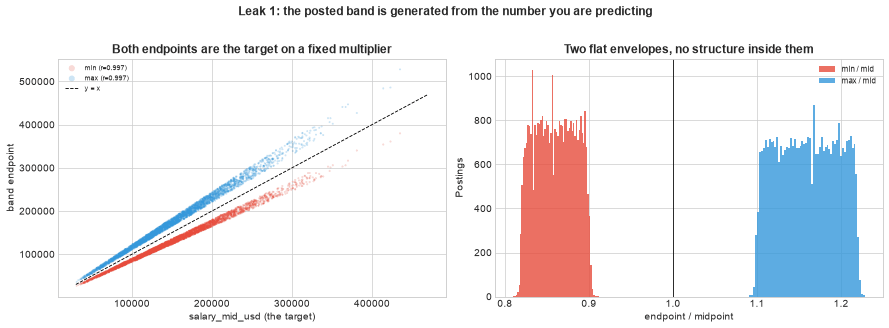

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sample = df.sample(4000, random_state=SEED)
ax1.scatter(sample[TARGET_COL], sample["salary_min_usd"], s=5, alpha=0.25,
            color="#e74c3c", edgecolors="none", label=f"min (r={corr.loc[TARGET_COL, 'salary_min_usd']:.3f})")
ax1.scatter(sample[TARGET_COL], sample["salary_max_usd"], s=5, alpha=0.25,
            color="#3498db", edgecolors="none", label=f"max (r={corr.loc[TARGET_COL, 'salary_max_usd']:.3f})")
limit = [df[TARGET_COL].min(), df[TARGET_COL].max()]
ax1.plot(limit, limit, color="black", linestyle="--", linewidth=1, label="y = x")
ax1.set_xlabel("salary_mid_usd (the target)")
ax1.set_ylabel("band endpoint")
ax1.set_title("Both endpoints are the target on a fixed multiplier", fontweight="bold")
ax1.legend(fontsize=8, markerscale=3)

ax2.hist(ratio_min, bins=60, color="#e74c3c", alpha=0.8, label="min / mid")
ax2.hist(ratio_max, bins=60, color="#3498db", alpha=0.8, label="max / mid")
ax2.axvline(1.0, color="black", linewidth=0.9)
ax2.set_xlabel("endpoint / midpoint")
ax2.set_ylabel("Postings")
ax2.set_title("Two flat envelopes, no structure inside them", fontweight="bold")
ax2.legend(fontsize=9)

plt.suptitle("Leak 1: the posted band is generated from the number you are predicting",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 8. The Second Leak: a Whole Table of Target Aggregates <a id='table-leak'></a>

`salary_benchmarks.csv` looks like an external reference — a market pay table you might
legitimately join on. It is not. Every one of its salary columns is a quantile of
`jobs.salary_mid_usd`, grouped by `(job_title, country, seniority, remote_type)`. Joining
it back onto `jobs` hands each posting a statistic computed **from a set that contains
that posting's own label**.

This is the same mistake as un-cross-validated target encoding, except it arrives
pre-packaged as a separate CSV, which makes it much easier to trust.

In [12]:
bm_keys = ["job_title", "country", "seniority", "remote_type"]
joined = jobs.merge(salary_benchmarks, on=bm_keys, how="left")
covered = joined["salary_median_usd"].notna()

# Reconstruct the benchmark table from jobs.csv to show it is a pure aggregate.
rebuilt = (
    jobs.groupby(bm_keys)
    .agg(n=("job_id", "size"),
         median_from_jobs=(TARGET_COL, "median"))
    .reset_index()
)
check = salary_benchmarks.merge(rebuilt, on=bm_keys, how="left")
exact = (check["salary_median_usd"] - check["median_from_jobs"]).abs().le(0.5).mean()

print("salary_benchmarks.csv is an aggregate of jobs.csv")
print("=" * 70)
print(f"Benchmark rows                       : {len(salary_benchmarks):,}")
print(f"Reproduced exactly from jobs.csv      : {exact:.1%} of them")
print(f"Postings that find a benchmark row    : {covered.mean():.1%} "
      f"(cells with <15 postings are dropped)")
print(f"Postings per benchmark cell (median)  : {check['n'].median():.0f}")
print()
print("What that means for a model:")
r_median = joined.loc[covered, "salary_median_usd"].corr(joined.loc[covered, TARGET_COL])
r_p10 = joined.loc[covered, "salary_p10_usd"].corr(joined.loc[covered, TARGET_COL])
r_p90 = joined.loc[covered, "salary_p90_usd"].corr(joined.loc[covered, TARGET_COL])
print(f"  r(salary_median_usd, own salary_mid_usd) = {r_median:.4f}")
print(f"  r(salary_p10_usd,    own salary_mid_usd) = {r_p10:.4f}")
print(f"  r(salary_p90_usd,    own salary_mid_usd) = {r_p90:.4f}")
print(f"  Each row contributes ~{1 / check['n'].median():.1%} of the median it is handed.")
print()
print("skill_demand_monthly.csv carries the same defect in median_salary_mid_usd,")
print("which is a monthly median of the same target column.")

salary_benchmarks.csv is an aggregate of jobs.csv
Benchmark rows                       : 618
Reproduced exactly from jobs.csv      : 100.0% of them
Postings that find a benchmark row    : 79.7% (cells with <15 postings are dropped)
Postings per benchmark cell (median)  : 29

What that means for a model:
  r(salary_median_usd, own salary_mid_usd) = 0.9198
  r(salary_p10_usd,    own salary_mid_usd) = 0.9173
  r(salary_p90_usd,    own salary_mid_usd) = 0.9175
  Each row contributes ~3.4% of the median it is handed.

skill_demand_monthly.csv carries the same defect in median_salary_mid_usd,
which is a monthly median of the same target column.


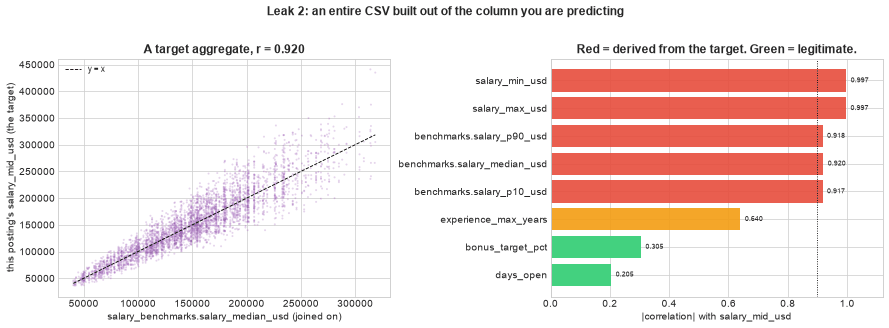

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sub = joined[covered].sample(4000, random_state=SEED)
ax1.scatter(sub["salary_median_usd"], sub[TARGET_COL], s=5, alpha=0.25,
            color="#9b59b6", edgecolors="none")
lims = [sub["salary_median_usd"].min(), sub["salary_median_usd"].max()]
ax1.plot(lims, lims, color="black", linestyle="--", linewidth=1, label="y = x")
ax1.set_xlabel("salary_benchmarks.salary_median_usd (joined on)")
ax1.set_ylabel("this posting's salary_mid_usd (the target)")
ax1.set_title(f"A target aggregate, r = {r_median:.3f}", fontweight="bold")
ax1.legend(fontsize=9)

leak_r = {
    "salary_min_usd": abs(corr.loc[TARGET_COL, "salary_min_usd"]),
    "salary_max_usd": abs(corr.loc[TARGET_COL, "salary_max_usd"]),
    "benchmarks.salary_p90_usd": abs(r_p90),
    "benchmarks.salary_median_usd": abs(r_median),
    "benchmarks.salary_p10_usd": abs(r_p10),
    "experience_max_years": abs(corr.loc[TARGET_COL, "experience_max_years"]),
    "bonus_target_pct": abs(corr.loc[TARGET_COL, "bonus_target_pct"]),
    "days_open": abs(corr.loc[TARGET_COL, "days_open"]),
}
labels = list(leak_r)[::-1]
values = [leak_r[k] for k in labels]
colors = ["#e74c3c" if v > 0.9 else "#f39c12" if v > 0.6 else "#2ecc71" for v in values]
bars = ax2.barh(labels, values, color=colors, alpha=0.9)
ax2.set_xlim(0, 1.12)
ax2.axvline(0.9, color="black", linestyle=":", linewidth=1)
ax2.set_xlabel("|correlation| with salary_mid_usd")
ax2.set_title("Red = derived from the target. Green = legitimate.", fontweight="bold")
for bar, v in zip(bars, values):
    ax2.text(v + 0.015, bar.get_y() + bar.get_height() / 2, f"{v:.3f}",
             va="center", fontsize=8)

plt.suptitle("Leak 2: an entire CSV built out of the column you are predicting",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 9. Target Analysis <a id='target'></a>

With the leaks identified, here is what the target actually looks like and which honest
columns move it.

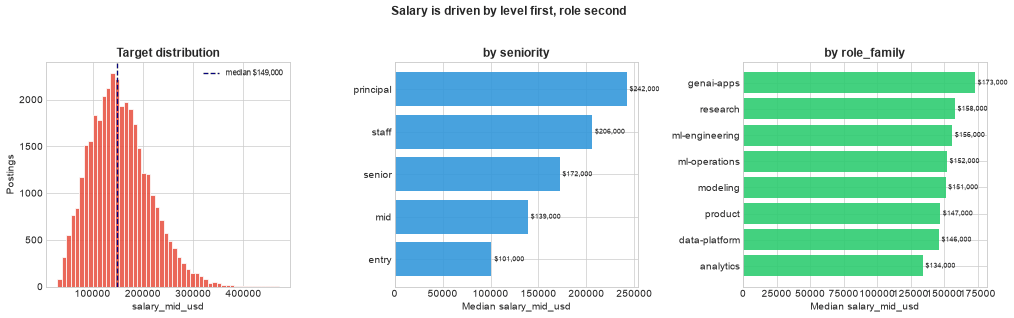

Median salary        : $149,000
Entry to principal   : $101,000 -> $242,000 (2.40x)
Cheapest to dearest role family: $134,000 -> $173,000 (1.29x)


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

axes[0].hist(df[TARGET_COL], bins=50, color="#e74c3c", alpha=0.85, edgecolor="white")
axes[0].axvline(df[TARGET_COL].median(), color="navy", linestyle="--",
                label=f"median ${df[TARGET_COL].median():,.0f}")
axes[0].set_xlabel(TARGET_COL)
axes[0].set_ylabel("Postings")
axes[0].set_title("Target distribution", fontweight="bold")
axes[0].legend(fontsize=9)

by_sen = df.groupby("seniority")[TARGET_COL].median().sort_values()
bars = axes[1].barh(by_sen.index, by_sen.values, color="#3498db", alpha=0.9)
axes[1].set_xlabel("Median salary_mid_usd")
axes[1].set_title("by seniority", fontweight="bold")
for bar, v in zip(bars, by_sen.values):
    axes[1].text(v + 3000, bar.get_y() + bar.get_height() / 2, f"${v:,.0f}",
                 va="center", fontsize=8)

by_fam = df.groupby("role_family")[TARGET_COL].median().sort_values()
bars = axes[2].barh(by_fam.index, by_fam.values, color="#2ecc71", alpha=0.9)
axes[2].set_xlabel("Median salary_mid_usd")
axes[2].set_title("by role_family", fontweight="bold")
for bar, v in zip(bars, by_fam.values):
    axes[2].text(v + 2000, bar.get_y() + bar.get_height() / 2, f"${v:,.0f}",
                 va="center", fontsize=8)

plt.suptitle("Salary is driven by level first, role second", fontsize=14,
             fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

print(f"Median salary        : ${df[TARGET_COL].median():,.0f}")
print(f"Entry to principal   : ${by_sen.min():,.0f} -> ${by_sen.max():,.0f} "
      f"({by_sen.max() / by_sen.min():.2f}x)")
print(f"Cheapest to dearest role family: ${by_fam.min():,.0f} -> ${by_fam.max():,.0f} "
      f"({by_fam.max() / by_fam.min():.2f}x)")

## 10. What the Leak Costs <a id='worth'></a>

Same model, same folds, same seed — only the feature set changes. Three feature sets:
the honest one, the honest one plus the two band endpoints, and the honest one plus the
joined benchmark aggregates.

In [15]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GroupKFold, cross_val_predict

CAT_FEATURES = ["job_title", "role_family", "seniority", "employment_type", "remote_type",
                "city", "country", "region", "industry", "company_size", "funding_stage",
                "education_required", "primary_skill_cluster", "cloud_stack"]
NUM_HONEST = ["experience_min_years", "experience_max_years", "bonus_target_pct",
              "equity_offered", "visa_sponsorship", "skills_count",
              "applications_30d", "days_open"]

model_frame = joined.copy()
y = model_frame[TARGET_COL]
groups = model_frame["company_id"]
cv = GroupKFold(n_splits=5)


def evaluate(numeric, cats=CAT_FEATURES):
    X = model_frame[cats + numeric].copy()
    for c in cats:
        X[c] = X[c].astype("category")
    model = HistGradientBoostingRegressor(
        random_state=SEED,
        categorical_features=[X.columns.get_loc(c) for c in cats],
    )
    pred = cross_val_predict(model, X, y, cv=cv, groups=groups)
    return mean_absolute_error(y, pred), r2_score(y, pred)


baseline_mae = mean_absolute_error(y, np.full(len(y), y.median()))
honest_mae, honest_r2 = evaluate(NUM_HONEST)
leaky_mae, leaky_r2 = evaluate(NUM_HONEST + ["salary_min_usd", "salary_max_usd"])
bm_mae, bm_r2 = evaluate(NUM_HONEST + ["salary_median_usd", "salary_p10_usd", "salary_p90_usd"])

print(f"5-fold GroupKFold on company_id, {model_frame['company_id'].nunique()} companies")
print("=" * 74)
print(f"{'feature set':<44} {'MAE':>12} {'R2':>8}")
print("-" * 74)
print(f"{'baseline: always the median salary':<44} ${baseline_mae:>11,.0f} {-0.0:>8.4f}")
print(f"{'honest (both leaks removed)':<44} ${honest_mae:>11,.0f} {honest_r2:>8.4f}")
print(f"{'+ salary_min_usd, salary_max_usd  [LEAK]':<44} ${leaky_mae:>11,.0f} {leaky_r2:>8.4f}")
print(f"{'+ salary_benchmarks aggregates    [LEAK]':<44} ${bm_mae:>11,.0f} {bm_r2:>8.4f}")
print("-" * 74)
print(f"The band endpoints hide {1 - leaky_mae / honest_mae:.1%} of the real error.")
print(f"The benchmark join changes MAE by {bm_mae / honest_mae - 1:+.1%} — it adds nothing,")
print("because a tree on (title, country, seniority, remote) already reconstructs the")
print("same cell means the benchmark table was built from. It is a leak that happens")
print("not to pay, which is the most dangerous kind: harmless here, free target")
print("encoding on a smaller sample or a linear model.")

5-fold GroupKFold on company_id, 280 companies
feature set                                           MAE       R2
--------------------------------------------------------------------------
baseline: always the median salary           $     46,788  -0.0000
honest (both leaks removed)                  $      8,664   0.9612
+ salary_min_usd, salary_max_usd  [LEAK]     $      2,620   0.9962
+ salary_benchmarks aggregates    [LEAK]     $      8,767   0.9605
--------------------------------------------------------------------------
The band endpoints hide 69.8% of the real error.
The benchmark join changes MAE by +1.2% — it adds nothing,
because a tree on (title, country, seniority, remote) already reconstructs the
same cell means the benchmark table was built from. It is a leak that happens
not to pay, which is the most dangerous kind: harmless here, free target
encoding on a smaller sample or a linear model.


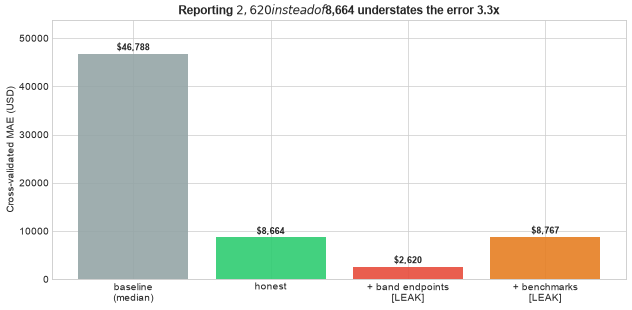

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
labels = ["baseline\n(median)", "honest", "+ band endpoints\n[LEAK]", "+ benchmarks\n[LEAK]"]
values = [baseline_mae, honest_mae, leaky_mae, bm_mae]
colors = ["#95a5a6", "#2ecc71", "#e74c3c", "#e67e22"]
bars = ax.bar(labels, values, color=colors, alpha=0.9)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + baseline_mae * 0.015,
            f"${v:,.0f}", ha="center", fontsize=10, fontweight="bold")
ax.set_ylabel("Cross-validated MAE (USD)")
ax.set_ylim(0, baseline_mae * 1.15)
ax.set_title(f"Reporting ${leaky_mae:,.0f} instead of ${honest_mae:,.0f} understates the error "
             f"{honest_mae / leaky_mae:.1f}x",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

## 11. Does the Multi-Table Join Pay? <a id='join'></a>

`job_skills.csv` is the largest table in the dataset by a factor of nine, and
`companies.csv` carries six employer attributes that `jobs.csv` does not. The obvious
hypothesis is that aggregating them onto each posting improves a salary model. This
section tests that rather than assuming it.

In [17]:
grouped_skills = job_skills.groupby("job_id")
skill_feats = pd.DataFrame({
    "n_skill_rows": grouped_skills.size(),
    "n_genai_skills": grouped_skills["is_genai_skill"].sum(),
    "genai_share": grouped_skills["is_genai_skill"].mean(),
    "core_share": grouped_skills["importance"].apply(lambda s: (s == "core").mean()),
    "expert_share": grouped_skills["proficiency_level"].apply(lambda s: (s == "expert").mean()),
    "n_skill_categories": grouped_skills["skill_category"].nunique(),
})

COMPANY_FEATS = ["employee_count_estimate", "remote_first", "ai_maturity_score",
                 "benefits_score", "glassdoor_like_rating", "hiring_velocity_index"]

model_frame = (
    joined.join(skill_feats, on="job_id")
    .merge(companies[["company_id"] + COMPANY_FEATS], on="company_id", how="left")
)
y = model_frame[TARGET_COL]
groups = model_frame["company_id"]

SKILL_FEATS = ["n_genai_skills", "genai_share", "core_share", "expert_share",
               "n_skill_categories"]

print(f"Skill aggregates cover {model_frame['n_skill_rows'].notna().mean():.1%} of postings")
print(f"Company attributes cover {model_frame['ai_maturity_score'].notna().mean():.1%} of postings")
print()

join_results = {
    "jobs.csv only (honest)": evaluate(NUM_HONEST),
    "+ job_skills aggregates": evaluate(NUM_HONEST + SKILL_FEATS),
    "+ companies profile": evaluate(NUM_HONEST + COMPANY_FEATS),
    "+ both": evaluate(NUM_HONEST + SKILL_FEATS + COMPANY_FEATS),
}
print(f"{'feature set':<32} {'MAE':>12} {'R2':>8} {'vs jobs.csv':>13}")
print("-" * 70)
ref = join_results["jobs.csv only (honest)"][0]
for label, (mae, r2) in join_results.items():
    print(f"{label:<32} ${mae:>11,.0f} {r2:>8.4f} {mae / ref - 1:>+12.2%}")
print("-" * 70)
print("None of the joins help. The honest reading is that title, seniority, country and")
print("role family already carry the whole salary signal, therefore adding 318,014 skill")
print("rows and 280 company profiles has nothing left to explain.")

Skill aggregates cover 100.0% of postings
Company attributes cover 100.0% of postings

feature set                               MAE       R2   vs jobs.csv
----------------------------------------------------------------------
jobs.csv only (honest)           $      8,664   0.9612       +0.00%
+ job_skills aggregates          $      8,669   0.9612       +0.07%
+ companies profile              $      8,828   0.9598       +1.90%
+ both                           $      8,807   0.9599       +1.65%
----------------------------------------------------------------------
None of the joins help. The honest reading is that title, seniority, country and
role family already carry the whole salary signal, therefore adding 318,014 skill
rows and 280 company profiles has nothing left to explain.


## 12. The GenAI Premium That Is Not There <a id='genai'></a>

The headline this dataset invites is "GenAI skills carry a pay premium". Postings that
list at least one GenAI skill do pay about **$21,000** more at the median, and that gap
survives within every seniority level, which is usually enough to convince people.

It does not survive `role_family`. The left panel below is why: GenAI skills are not
distributed across roles at all — they appear in three role families and are completely
absent from the other five. So comparing GenAI to non-GenAI postings is mostly comparing
`genai-apps` and `research` roles to `analytics` and `data-platform` roles, which differ
in pay for reasons that have nothing to do with the skill list.

In [18]:
model_frame["has_genai"] = model_frame["n_genai_skills"].fillna(0) > 0

raw_gap = (model_frame[model_frame["has_genai"]][TARGET_COL].median()
           - model_frame[~model_frame["has_genai"]][TARGET_COL].median())

print(f"Raw median premium for listing >=1 GenAI skill: ${raw_gap:,.0f}")
print()
print("The usual robustness check — does it survive inside each seniority level?")
by_level = (model_frame.groupby(["seniority", "has_genai"])[TARGET_COL]
            .median().unstack())
by_level["premium"] = by_level[True] - by_level[False]
for level, row in by_level.sort_values("premium").iterrows():
    print(f"  {level:<10} ${row[False]:>8,.0f} -> ${row[True]:>8,.0f}   "
          f"premium ${row['premium']:>+8,.0f}")
print(f"  It survives in {int((by_level['premium'] > 0).sum())} of "
      f"{len(by_level)} levels, so the naive check passes. That is the trap.")
print()
print("Share of postings with a GenAI skill, by role_family:")
by_family = model_frame.groupby("role_family")["has_genai"].mean().sort_values(ascending=False)
for family, share in by_family.items():
    print(f"  {family:<16} {share:>7.1%}")
print()

# Like-for-like: compare inside matched (title, seniority, country, remote) cells.
MATCH = ["job_title", "seniority", "country", "remote_type"]
deltas = []
for _key, group in model_frame.groupby(MATCH):
    if group["has_genai"].nunique() == 2 and len(group) >= 30:
        deltas.append(group[group["has_genai"]][TARGET_COL].median()
                      - group[~group["has_genai"]][TARGET_COL].median())
deltas = pd.Series(deltas)

print(f"Matched cells with both kinds of posting and >=30 rows: {len(deltas)}")
print(f"  median within-cell premium : ${deltas.median():,.0f}")
print(f"  mean within-cell premium   : ${deltas.mean():,.0f}")
print(f"  cells where GenAI pays more: {(deltas > 0).mean():.1%}")
print()
print(f"The ${raw_gap:,.0f} headline collapses to ${deltas.median():,.0f} once you compare like")
print("with like, and the sign is close to a coin flip. Therefore the premium is a")
print("role-composition effect, not a skill effect — which is also why the skill")
print("aggregates in Section 11 added nothing to the model.")

Raw median premium for listing >=1 GenAI skill: $21,000

The usual robustness check — does it survive inside each seniority level?
  entry      $  97,000 -> $ 111,000   premium $ +14,000
  mid        $ 135,000 -> $ 154,000   premium $ +19,000
  senior     $ 167,000 -> $ 193,000   premium $ +26,000
  staff      $ 199,000 -> $ 231,000   premium $ +32,000
  principal  $ 234,000 -> $ 272,000   premium $ +38,000
  It survives in 5 of 5 levels, so the naive check passes. That is the trap.

Share of postings with a GenAI skill, by role_family:
  genai-apps        100.0%
  research           99.0%
  product            85.4%
  analytics           0.0%
  data-platform       0.0%
  ml-engineering      0.0%
  ml-operations       0.0%
  modeling            0.0%

Matched cells with both kinds of posting and >=30 rows: 17
  median within-cell premium : $500
  mean within-cell premium   : $-88
  cells where GenAI pays more: 52.9%

The $21,000 headline collapses to $500 once you compare like
with like,

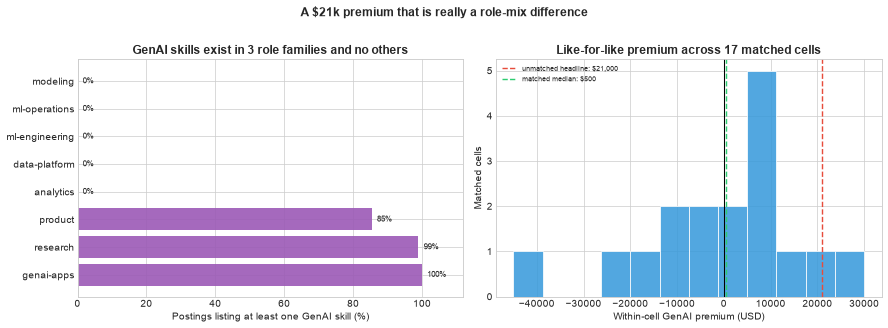

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

bars = ax1.barh(by_family.index, by_family.values * 100, color="#9b59b6", alpha=0.9)
ax1.set_xlim(0, 112)
ax1.set_xlabel("Postings listing at least one GenAI skill (%)")
ax1.set_title("GenAI skills exist in 3 role families and no others", fontweight="bold")
for bar, v in zip(bars, by_family.values * 100):
    ax1.text(v + 1.5, bar.get_y() + bar.get_height() / 2, f"{v:.0f}%",
             va="center", fontsize=9)

ax2.hist(deltas, bins=12, color="#3498db", alpha=0.85, edgecolor="white")
ax2.axvline(0, color="black", linewidth=1.2)
ax2.axvline(raw_gap, color="#e74c3c", linestyle="--", linewidth=1.6,
            label=f"unmatched headline: ${raw_gap:,.0f}")
ax2.axvline(deltas.median(), color="#2ecc71", linestyle="--", linewidth=1.6,
            label=f"matched median: ${deltas.median():,.0f}")
ax2.set_xlabel("Within-cell GenAI premium (USD)")
ax2.set_ylabel("Matched cells")
ax2.set_title(f"Like-for-like premium across {len(deltas)} matched cells", fontweight="bold")
ax2.legend(fontsize=8)

plt.suptitle("A $21k premium that is really a role-mix difference", fontsize=13,
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 13. Evaluation Readiness <a id='evaluation'></a>

In [20]:
print("Evaluation readiness checklist")
print("=" * 74)
print(f"Target        : {TARGET_COL}")
print(f"Task          : {MODELING_TASK}")
print(f"Metric        : {PRIMARY_METRIC}")
print(f"Validation    : {VALIDATION_PLAN}")
print(f"Baseline      : MAE ${baseline_mae:,.0f} (always predict the median)")
print(f"Honest target : MAE ${honest_mae:,.0f}, R2 {honest_r2:.4f}")
print()
print("DROP these before modelling salary_mid_usd:")
print("  salary_min_usd, salary_max_usd            generated from the target")
print("  salary_benchmarks.salary_p10/median/p90   quantiles of the target")
print("  skill_demand_monthly.median_salary_mid_usd monthly median of the target")
print()
print("Legitimate and useful:")
print("  job_title, role_family, seniority, country, remote_type, industry")
print("  experience_min_years, experience_max_years, bonus_target_pct")
print()
print("Legitimate but nearly inert (measured in section 11):")
print("  job_skills aggregates, companies profile columns")
print()
print("Aggregation hygiene:")
print("  - Group folds by company_id. 280 companies over 36,000 rows means a random")
print("    split trains and tests on the same employer's pay bands.")
print("  - If you build your own market-rate feature, compute it OUT OF FOLD. That is")
print("    exactly the step salary_benchmarks.csv skipped.")
print("  - llm_stack NaN means 'no LLM requirement'. Fill with a sentinel category,")
print("    never with the mode.")

Evaluation readiness checklist
Target        : salary_mid_usd
Task          : regression
Metric        : MAE in USD (R2 alongside)
Validation    : 5-fold GroupKFold on company_id
Baseline      : MAE $46,788 (always predict the median)
Honest target : MAE $8,664, R2 0.9612

DROP these before modelling salary_mid_usd:
  salary_min_usd, salary_max_usd            generated from the target
  salary_benchmarks.salary_p10/median/p90   quantiles of the target
  skill_demand_monthly.median_salary_mid_usd monthly median of the target

Legitimate and useful:
  job_title, role_family, seniority, country, remote_type, industry
  experience_min_years, experience_max_years, bonus_target_pct

Legitimate but nearly inert (measured in section 11):
  job_skills aggregates, companies profile columns

Aggregation hygiene:
  - Group folds by company_id. 280 companies over 36,000 rows means a random
    split trains and tests on the same employer's pay bands.
  - If you build your own market-rate feature, co

## 14. Key Findings & Takeaways <a id='findings'></a>

Every number below is printed by a cell above. Nothing is asserted that the notebook does
not also compute.

### Finding 1 — two columns are the target with a multiplier on it

`salary_min_usd` and `salary_max_usd` correlate with `salary_mid_usd` at **0.9972** and
**0.9965**. The ratio evidence settles what that means: `min/mid` spans 0.810 to 0.912
and `max/mid` spans 1.091 to 1.229, with the same range inside every seniority level.
There is no role, level or country structure in those ratios **because** there is nothing
in them but a uniform multiplier applied to the target. Keeping them cuts cross-validated
MAE from **$8,664 to $2,620** — a model that looks 3.3× better than it is.

### Finding 2 — the second leak is an entire CSV, and it is the harder one to spot

`salary_benchmarks.csv` reads like an external market reference and is in fact
`jobs.groupby([title, country, seniority, remote]).salary_mid_usd.quantile()`. Joined
back on, its median column correlates **0.920** with the very label you are predicting,
and each posting contributes about **3.4%** of the number it is handed. Notably it does
**not** improve the model (MAE moves **+1.2%**), which is worse than if it had: a leak
that pays nothing attracts no scrutiny, and the same join on a smaller sample or under a
linear model would be free out-of-fold target encoding.

### Finding 3 — the multi-table join does not pay here

Aggregating 318,014 skill rows and 280 company profiles onto each posting moves MAE from
**$8,664** to **$8,669** (skills), **$8,828** (companies) and **$8,807** (both). This is
a negative result worth having: it says the pay signal is fully carried by title,
seniority, country and role family, **therefore** effort spent engineering skill features
for a salary model is effort wasted. It would be a different answer for a different
target — `days_open` or `applications_30d` have no such shortcut.

### Finding 4 — the GenAI pay premium is a role-mix artefact

Postings listing at least one GenAI skill pay **$21,000** more at the median, and the gap
holds within every seniority level, which is the check most analyses stop at. But GenAI
skills appear in **100%** of `genai-apps`, **99.0%** of `research` and **85.4%** of
`product` postings and in **0%** of the other five role families. Compare like with like —
inside matched (title, seniority, country, remote) cells — and the median premium is
**$500** across 17 comparable cells, with only **52.9%** of them positive. The trade-off
this illustrates is general: stratifying on one covariate is not stratification, and the
covariate that explains the gap is usually the one that determines who is in each group.

### Limitations and caveats

- **This data is synthetic.** Salaries come from a seeded generator with per-role base
  bands, not from real postings. The structures found above are properties of that
  generator; treat every dollar figure as an exercise, not a market rate.
- **17 matched cells is a small comparison set.** The like-for-like GenAI premium in
  Finding 4 is measured on the cells large enough to support it, and its confidence
  interval comfortably contains zero. The strong claim is the confound, not the exact $500.
- **280 companies is a small group count** for a 5-fold grouped split, so the honest MAE
  of $8,664 carries fold-to-fold variance; read it as "roughly $8-9k", not a precise
  figure.
- **`salary_currency` has one value** (USD) and `is_filled`, `applications_30d` correlate
  with the target at under 0.02, so several columns in this table are decoration.
- **EDA cannot establish causality.** The GenAI result shows a confound, which is not the
  same as showing that GenAI skills have no value; it shows this table cannot answer that
  question.

### Conclusion and next steps

The single habit this dataset teaches: before joining a table, ask what its columns were
computed *from*. One of the four auxiliary tables here is built out of the label, and it
is the one that looks most like legitimate outside knowledge.

Recommended next steps:

- **Model `days_open` or `applications_30d` instead.** Neither has a leaked twin, both are
  weakly predicted by the honest columns, and the skill and company tables would finally
  have room to contribute.
- **Rebuild the market-rate feature out of fold.** Recompute `salary_benchmarks` inside
  each training fold and re-run Section 10; the difference between that and the shipped
  table is the size of the leak, measured directly.
- **Model the skill graph properly.** `job_skills.csv` has 70 skills over 13 categories;
  a co-occurrence graph or per-skill indicator matrix is a much better use of it than the
  six scalar aggregates tried in Section 11.
- **Test the GenAI premium with a matched design at scale.** Propensity-match on role
  family and seniority rather than filtering to cells with 30+ rows, which would improve
  on the 17-cell comparison this notebook could afford.

*The data is synthetic and generated by a seeded script. It is built for teaching,
benchmarking and prototyping, not for drawing conclusions about the real jobs market.*